In [21]:
import numpy as np
import matplotlib.pyplot as plt


def integrand(a, k, x):
    return a / (1 + (k * x)**2)

def exact_integral(a, k):
    return a * np.arctan(k) / k



# truncated exponential proposal q_lambda(x)
def sample_truncated_exponential(lam, size):
    u = np.random.uniform(0, 1, size)
    return -np.log(1 - u * (1 - np.exp(-lam))) / lam

def truncated_exponential_pdf(lam, x):
    return lam * np.exp(-lam * x) / (1 - np.exp(-lam))



def standard_mc_estimate(a, k, num_samples):
    x = np.random.uniform(0, 1, num_samples)
    return np.mean(integrand(a, k, x))

def importance_sampling_estimate(a, k, lam, num_samples):
    x = sample_truncated_exponential(lam, num_samples)
    qx = truncated_exponential_pdf(lam, x)

    weights = integrand(a, k, x) / qx
    return np.mean(weights)



# experiment parameters
a = 10
k = 100
lam = 10

num_experiments = 1000
sample_sizes = np.array([100, 300, 1000, 3000, 10000])

I_exact = exact_integral(a, k)

standard_estimates = {}
importance_estimates = {}

for N in sample_sizes:
    standard_estimates[N] = np.zeros(num_experiments)
    importance_estimates[N] = np.zeros(num_experiments)

    for experiment in range(num_experiments):
        standard_estimates[N][experiment] = standard_mc_estimate(a, k, N)
        importance_estimates[N][experiment] = importance_sampling_estimate(a, k, lam, N)

    print(f"N = {N}")
    print(f"  Exact value:              {I_exact:.8f}")
    print(f"  Standard MC mean:         {np.mean(standard_estimates[N]):.8f}")
    print(f"  Importance Sampling mean: {np.mean(importance_estimates[N]):.8f}")
    print(f"  Standard MC variance:     {np.var(standard_estimates[N]):.8e}")
    print(f"  Importance variance:      {np.var(importance_estimates[N]):.8e}")
    print()




N = 100
  Exact value:              0.15607967
  Standard MC mean:         0.16157530
  Importance Sampling mean: 0.15546716
  Standard MC variance:     8.05681866e-03
  Importance variance:      5.87644857e-04

N = 300
  Exact value:              0.15607967
  Standard MC mean:         0.15762096
  Importance Sampling mean: 0.15684798
  Standard MC variance:     2.64958440e-03
  Importance variance:      1.95744665e-04

N = 1000
  Exact value:              0.15607967
  Standard MC mean:         0.15595014
  Importance Sampling mean: 0.15604351
  Standard MC variance:     7.54552071e-04
  Importance variance:      6.00844573e-05

N = 3000
  Exact value:              0.15607967
  Standard MC mean:         0.15592748
  Importance Sampling mean: 0.15600536
  Standard MC variance:     2.67640268e-04
  Importance variance:      1.99596715e-05

N = 10000
  Exact value:              0.15607967
  Standard MC mean:         0.15589839
  Importance Sampling mean: 0.15611435
  Standard MC variance:

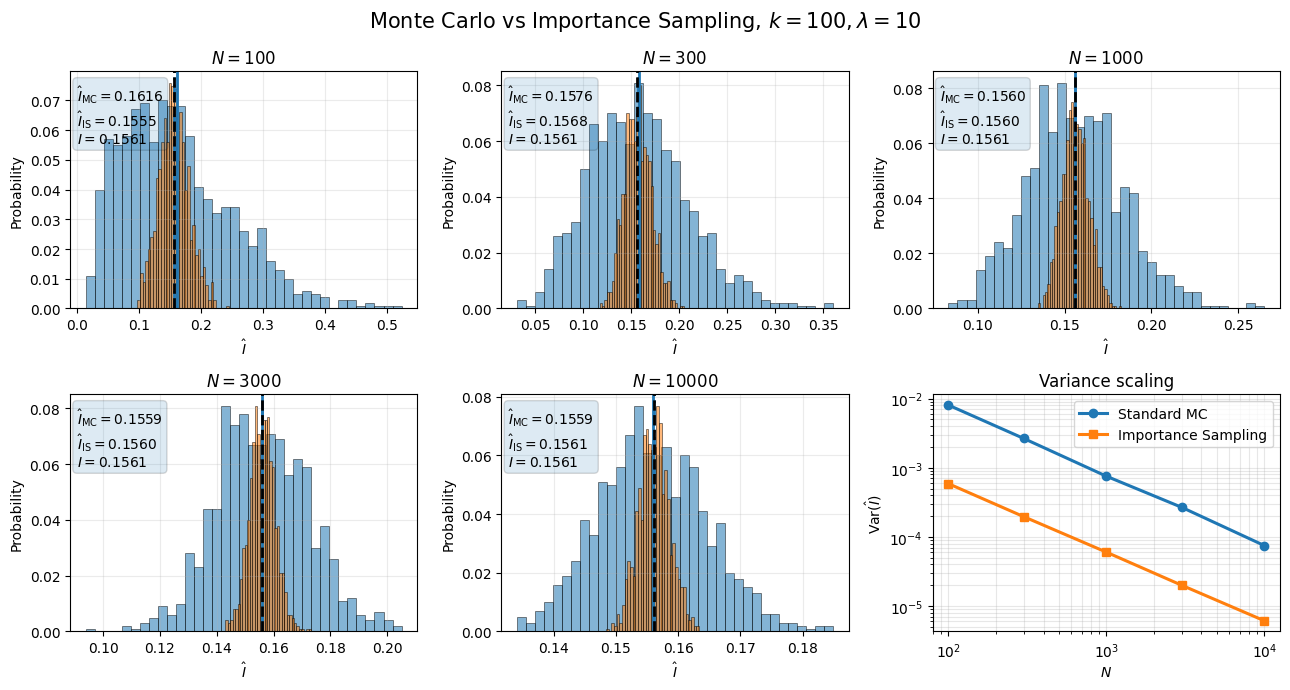

In [22]:
selected_sizes = sample_sizes

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for ax, N in zip(axes[:-1], selected_sizes):

    data_mc = standard_estimates[N].flatten()
    data_is = importance_estimates[N].flatten()

    bins = 35

    weights_mc = np.ones_like(data_mc) / len(data_mc)
    weights_is = np.ones_like(data_is) / len(data_is)

    ax.hist(
        data_mc,
        bins=bins,
        weights=weights_mc,
        alpha=0.55,
        edgecolor="black",
        linewidth=0.6,
        label="Standard MC"
    )

    ax.hist(
        data_is,
        bins=bins,
        weights=weights_is,
        alpha=0.55,
        edgecolor="black",
        linewidth=0.6,
        label="Importance Sampling"
    )

    mean_mc = np.mean(data_mc)
    mean_is = np.mean(data_is)

    ax.axvline(mean_mc, linestyle="-", linewidth=2)
    ax.axvline(mean_is, linestyle="-.", linewidth=2)
    ax.axvline(I_exact, linestyle="--", linewidth=2, color="black")

    text_str = (
        rf"$\hat I_\mathrm{{MC}} = {mean_mc:.4f}$" "\n"
        rf"$\hat I_\mathrm{{IS}} = {mean_is:.4f}$" "\n"
        rf"$I = {I_exact:.4f}$"
    )

    ax.text(
        0.02, 0.95,
        text_str,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", alpha=0.15)
    )

    ax.set_title(rf"$N={N}$")
    ax.set_xlabel(r"$\hat I$")
    ax.set_ylabel("Probability")
    ax.grid(alpha=0.25)

var_standard = np.array([np.var(standard_estimates[N]) for N in sample_sizes])
var_importance = np.array([np.var(importance_estimates[N]) for N in sample_sizes])

ax = axes[-1]

ax.loglog(sample_sizes, var_standard, marker="o", linewidth=2.2, label="Standard MC")
ax.loglog(sample_sizes, var_importance, marker="s", linewidth=2.2, label="Importance Sampling")

ax.set_xlabel(r"$N$")
ax.set_ylabel(r"$\mathrm{Var}(\hat I)$")
ax.set_title("Variance scaling")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

fig.suptitle(
    rf"Monte Carlo vs Importance Sampling, $k={k}, \lambda={lam}$",
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "mc_vs_importance_sampling.pdf",
    format="pdf",
    bbox_inches="tight",
    dpi=600
)

plt.show()